<a href="https://colab.research.google.com/github/AichaELMouta/Books_sales_Regression/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

100%|██████████| 292k/292k [00:00<00:00, 28.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4


In [3]:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn import metrics
from sklearn import preprocessing


Loading Dataset from csv file to pandas dataframe

In [5]:
car_data=pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/car data.csv")

In [6]:
#Inspecting data
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
car_data.shape

(301, 9)

In [8]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
#show duplicated rows
car_data[car_data.duplicated(keep=False)]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


Drop duplicates rows

In [10]:
#drop duplicated rows
car_data.drop_duplicates(inplace=True)
car_data = car_data.reset_index(drop=True)
car_data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
294,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
295,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
296,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
297,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [11]:
car_data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [12]:
car_data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [13]:
car_data.Car_Name.value_counts()

,count
Car_Name,
city,26
corolla altis,16
verna,14
brio,10
fortuner,10
...,...
Honda Activa 125,1
Hero Hunk,1
Hero Ignitor Disc,1


In [14]:
#checking the categorical data
print(car_data.Fuel_Type.value_counts())
print(car_data.Transmission.value_counts())
print(car_data.Seller_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64


In [15]:
car_data.Owner.value_counts()

,count
Owner,
0,288
1,10
3,1


**Exploratory DATA Analysis EDA with statistics**

In [16]:
# statistical measures of the dataset
car_data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Test Each variable


1.   Transmission







In [17]:
# number of values for each brand
import plotly.express as px
px.histogram(car_data , x = 'Transmission' ,  text_auto = '.1f' , title = 'Transmission Range')

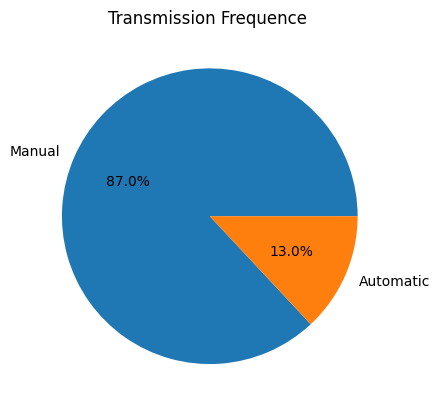

In [18]:
percentages = car_data['Transmission'].value_counts(normalize=True) * 100
plt.pie(percentages, labels=percentages.index,
        autopct='%1.1f%%')
plt.title('Transmission Frequence ')
plt.show()

In [19]:
from scipy.stats import ttest_ind
group1 = car_data[car_data['Transmission']=="Manual"]['Selling_Price']
group2 = car_data[car_data['Transmission']=="Automatic"]['Selling_Price']
results = ttest_ind(group1, group2)
print('Degree of Freedom:', {results.df})
print('p-value:', {results.pvalue})
print('t-statistic:', {results.statistic})


Degree of Freedom: {np.float64(297.0)}
p-value: {np.float64(5.532298979959338e-10)}
t-statistic: {np.float64(-6.415357573143541)}


1- P_value

P_value << 0.05  that means we can reject the null hypothesis because the difference between the two groups is statistically significant. based on p_value result we can conclude that transmission variable affects the selling price of cars.

2- T_statistic

t_statistic = -6.415  is very strong separation that means Manual Transmission and Automatic transmission have different average.

3- Degree of freedom

df = 297

The test is reliable



In [20]:
car_data.groupby('Transmission')['Selling_Price'].mean()

,Selling_Price
Transmission,
Automatic,9.071795
Manual,3.917308


The group means indicate that Automatic cars have a higher average 9.07 compared to those Manual cars.
This suggests that this feature contains meaningful predictive information and should be considered in the modeling phase.

In [21]:
def cohens_d(group1, group2):
  group1 = car_data[car_data['Transmission']=="Manual"]['Selling_Price']
  group2 = car_data[car_data['Transmission']=="Automatic"]['Selling_Price']
  n1, n2 = len(group1), len(group2)
  s1, s2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
  pooled_std = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
  return (np.mean(group1) - np.mean(group2)) / pooled_std
cohens_d(group1, group2)

np.float64(-1.1016343884869506)

Cohen's d = 1.01  based on this parameter of Cohens_d we can say that transmission variable is a strong predictor for car selling price.

    2- Seller Type

In [22]:
# Seller Type Variable
px.histogram(car_data , x = 'Seller_Type' ,  text_auto = '.1f' , title = 'Seller Type Range')

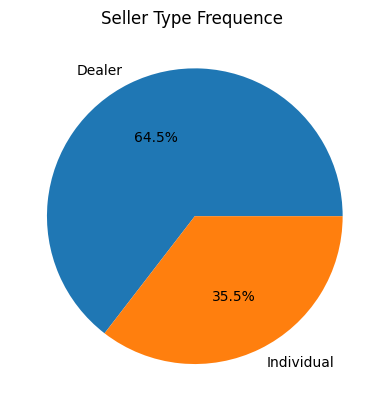

In [23]:
pourcentages = car_data['Seller_Type'].value_counts(normalize=True) * 100
plt.pie(pourcentages, labels=pourcentages.index,
        autopct='%1.1f%%')
plt.title('Seller Type Frequence ')
plt.show()

Hypothesis test and statistical analysis

In [24]:
group1 = car_data[car_data['Seller_Type']=="Individual"]['Selling_Price']
group2 = car_data[car_data['Seller_Type']=="Dealer"]['Selling_Price']
results = ttest_ind(group1, group2)
print('P_value:', {results.pvalue})
print('T_statistic:', {results.statistic})
print('Degree of Freedom:', {results.df})

P_value: {np.float64(1.952899027516022e-25)}
T_statistic: {np.float64(-11.463733809180827)}
Degree of Freedom: {np.float64(297.0)}


 1- P_value

P_value = 1.95e-25 << 0.05 that means we can reject the null hypothesis because the difference between the two groups is statistically significant. based on p_value result we can conclude that Seller Type variable affects the selling price of cars.

2- T_statistic

t_statistic = -11.46 is very strong separation that means Dealer seller  and Individual seller have different average.

3- Degree of freedom

df = 297

The test is reliable

In [25]:
car_data.groupby('Seller_Type')['Selling_Price'].mean()

,Selling_Price
Seller_Type,
Dealer,6.632021
Individual,0.870943


The group means indicate that Dealer seller have a higher average 6.63 compared to those Individual seller. This suggests that this feature contains meaningful predictive information and should be considered in the modeling phase.

In [26]:
#Cohens_d parameter
def cohens_d(group1, group2):
  group1 = car_data[car_data['Seller_Type']=="Dealer"]['Selling_Price']
  group2 = car_data[car_data['Seller_Type']=="Individual"]['Selling_Price']
  n1, n2 = len(group1), len(group2)
  s1, s2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
  pooled_std = np.sqrt(((n1 -n2) * s1 + (n2 - n1) * s2) / (n1 + n2 - 2))
  return (np.mean(group1) - np.mean(group2)) / pooled_std
cohens_d(group1, group2)


np.float64(2.240413224585212)

Cohens_d = 2.24  based on this parameter of Cohens_d we can say that seller type variable is a strong predictor for car selling price.

3- Fuel Type

In [27]:
px.histogram(car_data , x = 'Fuel_Type' ,  text_auto = '.1f' , title = 'Fuel type Range')

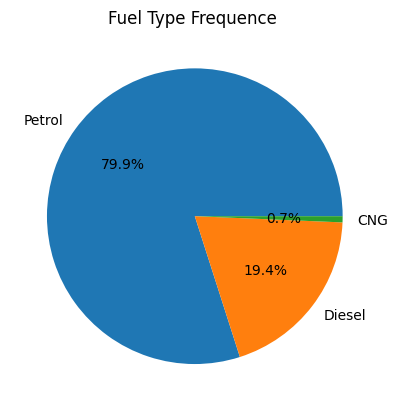

In [28]:
pourcentages = car_data['Fuel_Type'].value_counts(normalize=True) * 100
plt.pie(pourcentages, labels=pourcentages.index,
        autopct='%1.1f%%')
plt.title('Fuel Type Frequence ')
plt.show()

Test of null hypothesis and statistical analysis

In [29]:
from scipy.stats import f_oneway
group1 = car_data[car_data['Fuel_Type']=="Petrol"]['Selling_Price']
group2 = car_data[car_data['Fuel_Type']=="Diesel"]['Selling_Price']
group3 = car_data[car_data['Fuel_Type']=="CNG"]['Selling_Price']
F_stat, p_value = f_oneway(group1, group2, group3)
print('p_value', p_value)
print('F_stat', F_stat)

p_value 3.1012300197759416e-23
F_stat 62.061249891630744


1- P_value

P_value = 3.10e-23 << 0.05 that means we can reject the null hypothesis because the difference between groups is statistically significant. based on p_value result we can conclude that Fuel Type variable affects the selling price of cars.

2- F_statistic

t_statistic = 62.06 is very strong difference between groups.

In [30]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=car_data['Selling_Price'],
    groups=car_data['Fuel_Type'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   CNG Diesel   7.0028 0.0547 -0.1087 14.1143  False
   CNG Petrol   0.1642 0.9983  -6.857  7.1853  False
Diesel Petrol  -6.8386    0.0 -8.2859 -5.3912   True
----------------------------------------------------


Based in Turkey HSD results we can say that CNG and Petrol have same behavior, but Petrol and Diesel are very different. So Fuel Type categorical feature is not random noise. Fuel Type contains real predictive information.

Owner

In [31]:
px.histogram(car_data , x = 'Owner' ,  text_auto = '.1f' , title = 'Owner Range')

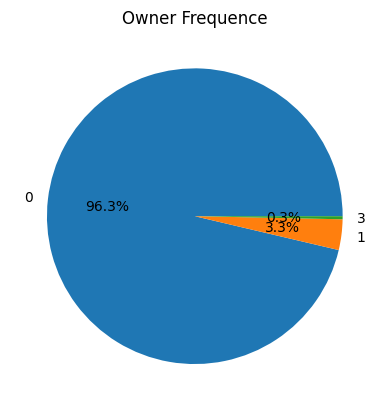

In [32]:
pourcentages = car_data['Owner'].value_counts(normalize=True) * 100
plt.pie(pourcentages, labels=pourcentages.index,
        autopct='%1.1f%%')
plt.title('Owner Frequence')
plt.show()

In [33]:
from scipy.stats import spearmanr
spearman_corr, p_value = spearmanr(car_data['Owner'], car_data['Selling_Price'])
print('Spearman correlation coefficient:', spearman_corr)
print('p-value:', p_value)

Spearman correlation coefficient: -0.14346639205485182
p-value: 0.013019562211863142


A Spearman correlation test showed a statistically significant negative relationship between the number of previous owners and selling price (ρ = −0.143, p = 0.013). However, the effect size is very weak, indicating that while cars with more owners tend to sell for slightly lower prices, the Owner variable has limited practical predictive power. We can test also by using ANOVA.

In [34]:
from scipy.stats import f_oneway
group1 = car_data[car_data['Owner']=="0"]['Selling_Price']
group2 = car_data[car_data['Owner']=="1"]['Selling_Price']
group3 = car_data[car_data['Owner']=="3+"]['Selling_Price']
group4 = car_data[car_data['Owner']=="2"]['Selling_Price']


In [35]:
px.histogram(car_data , x = 'Car_Name' ,  text_auto = '.1f' , title = 'Car Name Range')

In [36]:
px.histogram(car_data , x = 'Year' ,  text_auto = '.1f' , title = 'Year Range')

In [37]:
#Convert Year to Age
np.max(car_data['Year'])
#To calculate the age of cars, 2019 will be considered the reference year.
car_data['Age'] = 2019 - car_data['Year']
car_data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,5
...,...,...,...,...,...,...,...,...,...,...
294,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,3
295,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,4
296,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,10
297,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,2


In [38]:
print('Skewness coeficient',car_data['Age'].skew())
print('The number of Null Value of Age variable',(car_data['Age'] == 0).sum())

Skewness coeficient 1.2368759011841435
The number of Null Value of Age variable 0


<Axes: xlabel='Age', ylabel='Count'>

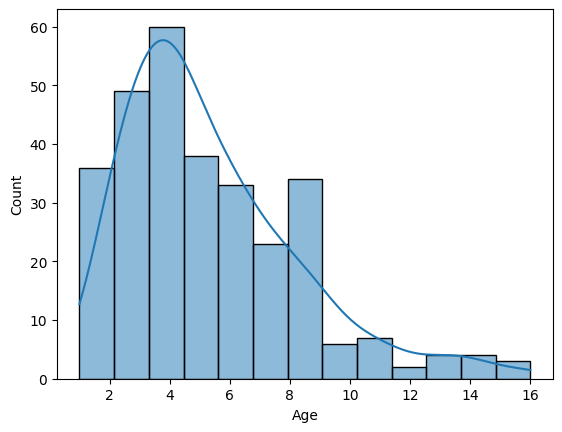

In [39]:
sns.histplot(car_data['Age'], kde=True)

Based on the coefficient of skewness of Age variable and graph, we can conclude that the age is strong posively skewness (right skewness). We could use Log transformation to reduce skewness.

Coeficient Log age: 0.03175096427821029


<Axes: xlabel='Age', ylabel='Count'>

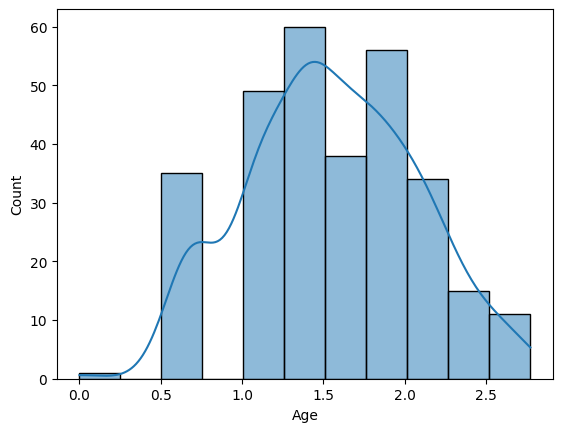

In [40]:
print('Coeficient Log age:', np.log(car_data['Age']).skew())
sns.histplot(np.log(car_data['Age']), kde=True)

In [41]:
car_data['Log_Age'] = np.log(car_data['Age'])

In [42]:
px.scatter(car_data, x='Log_Age', y='Selling_Price',  height = 600 , width =1000 ,title = 'Log age Vs Selling Price', size='Selling_Price', template = 'plotly_dark')

In [43]:
# Calculate the correlation matrix
import scipy.stats as stats
correlation_coefficient, p_value = stats.pearsonr(car_data['Log_Age'], car_data['Selling_Price'])

print(f"SciPy Pearson correlation coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

SciPy Pearson correlation coefficient: -0.23400034024454408
P-value: 4.385564275215162e-05


Based in this resulat r = -0,234 AND p-value = 4.3855e-05, we can conclude that there is a statistically significant but weak negative linear relationship between Age and Selling price.

 Kms_Driven

In [44]:
px.histogram(car_data , x = 'Kms_Driven' ,  text_auto = '.1f' , title = 'Kms_Driven Range')

In [45]:
car_data['Kms_Driven'].skew()

np.float64(6.418134387971488)

<Axes: xlabel='Kms_Driven', ylabel='Count'>

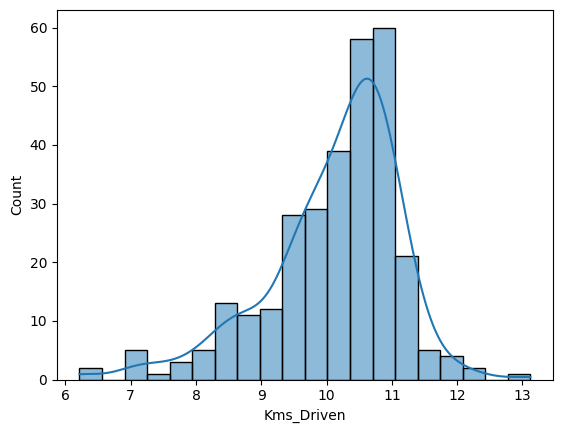

In [46]:
sns.histplot(np.log(car_data['Kms_Driven']), kde=True)

In [47]:
(car_data['Kms_Driven'] == 0).sum()

np.int64(0)

In [48]:
car_data['Log_Kms_Driven'] = np.log(car_data['Kms_Driven'])

<Axes: xlabel='Log_Kms_Driven', ylabel='Count'>

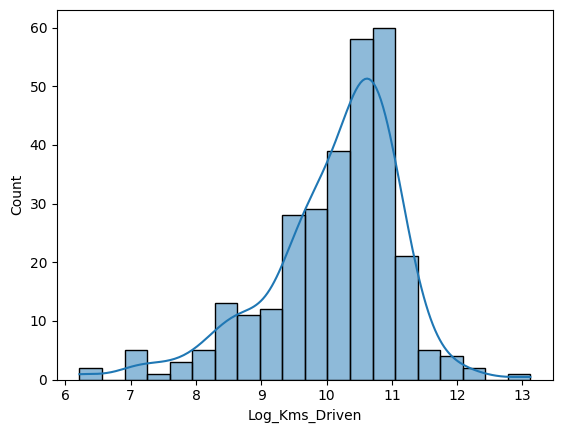

In [49]:
sns.histplot(car_data['Log_Kms_Driven'], kde=True)

In [50]:
car_data['Log_Kms_Driven'].skew()

np.float64(-1.0394083295200534)

After applying log transformation, the distribution of Kms_Driven became strongly left-skewed (-1.04), meaning the transforamation may have over-corrected the original right skew.

Statisticak analysis

In [51]:
from scipy.stats import pearsonr
correlation_coefficient, p_value = pearsonr(car_data['Log_Kms_Driven'], car_data['Selling_Price'])

print(f"SciPy Pearson correlation coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

SciPy Pearson correlation coefficient: 0.12122449510185697
P-value: 0.03616033603968142


there is a statistically significant but very weak positive linear relationship between kms_driven and selling_price.

 Present Price

In [52]:
px.scatter (car_data , x = 'Present_Price' , y = 'Selling_Price' , height = 600 , width =1000 ,title = 'Present Price Vs Selling Price',size='Selling_Price', template = 'plotly_dark' )

In [53]:
import scipy.stats as stats
correlation_coefficient, p_value = stats.pearsonr(car_data['Present_Price'], car_data['Selling_Price'])

print(f"Scipy Pearson correlation coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

Scipy Pearson correlation coefficient: 0.876378180060999
P-value: 3.063866979552786e-96


There is a verystrong and highly statistically significant positive linear relationship between the two variables selling price and present price. (r= 0.876, P< 0.001)

**Data Scaling**


***Data*** **Encoding**
```Encoder categorical variables```



In [54]:
encoder = LabelEncoder()
car_data['Transmission'] = encoder.fit_transform(car_data['Transmission'])
car_data['Fuel_Type'] = encoder.fit_transform(car_data['Fuel_Type'])
car_data['Seller_Type'] = encoder.fit_transform(car_data['Seller_Type'])


In [55]:
car_data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age,Log_Age,Log_Kms_Driven
0,ritz,2014,3.35,5.59,27000,2,0,1,0,5,1.609438,10.203592
1,sx4,2013,4.75,9.54,43000,1,0,1,0,6,1.791759,10.668955
2,ciaz,2017,7.25,9.85,6900,2,0,1,0,2,0.693147,8.839277
3,wagon r,2011,2.85,4.15,5200,2,0,1,0,8,2.079442,8.556414
4,swift,2014,4.60,6.87,42450,1,0,1,0,5,1.609438,10.656082
...,...,...,...,...,...,...,...,...,...,...,...,...
294,city,2016,9.50,11.60,33988,1,0,1,0,3,1.098612,10.433763
295,brio,2015,4.00,5.90,60000,2,0,1,0,4,1.386294,11.002100
296,city,2009,3.35,11.00,87934,2,0,1,0,10,2.302585,11.384342
297,city,2017,11.50,12.50,9000,1,0,1,0,2,0.693147,9.104980


In [56]:
X = car_data.drop(['Car_Name','Selling_Price', 'Age', 'Kms_Driven', 'Year'],axis=1)
Y = car_data['Selling_Price']

In [57]:
corr_X_Y = X.corrwith(Y)
corr_X_Y

,0
Present_Price,0.876378
Fuel_Type,-0.500292
Seller_Type,-0.553851
Transmission,-0.348869
Owner,-0.087880
Log_Age,-0.234000
Log_Kms_Driven,0.121224


**Splitting** **Data**

In [58]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [59]:
X_train.shape

(239, 7)

In [60]:
X_test.shape

(60, 7)

**Model Training**

*Linear Regression*


In [61]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

LinearRegression()

In [62]:
lr_predict_train = lr.predict(X_train)
lr_predict_test = lr.predict(X_test)

In [63]:
mae_tr = metrics.mean_absolute_error(Y_train, lr_predict_train)
rmse_tr_lr = metrics.mean_squared_error(Y_train, lr_predict_train)
mae_ts = metrics.mean_absolute_error(Y_test, lr_predict_test)
rmse_ts = metrics.mean_squared_error(Y_test, lr_predict_test)
R2_tr_lr = metrics.r2_score(Y_train, lr_predict_train)
R2_ts = metrics.r2_score(Y_test, lr_predict_test)
print("MAE of train data:", mae_tr)
print("MAE of test data:", mae_ts)
print("RMSE of train data:", rmse_tr_lr)
print("RMSE of test data:", rmse_ts)
print("R2 of train data:", R2_tr_lr)
print("R2 of test data:", R2_ts)

MAE of train data: 1.1689314971148368
MAE of test data: 1.2866895376982541
RMSE of train data: 2.9594481634573837
RMSE of test data: 3.9206767303391366
R2 of train data: 0.8887699124686124
R2 of test data: 0.7643875191839932


In [64]:
Y.std()

4.984239677845962

*Lasso* *Regression*

In [65]:
lasso_model = Lasso()
lasso_model.fit(X_train, Y_train)

Lasso()

In [66]:
lasso_model_predict_train = lasso_model.predict(X_train)
lasso_model_predict_test = lasso_model.predict(X_test)


In [67]:
mae_tr = metrics.mean_absolute_error(Y_train, lasso_model_predict_train)
rmse_tr_lasso = metrics.mean_squared_error(Y_train, lasso_model_predict_train)
mae_ts = metrics.mean_absolute_error(Y_test, lasso_model_predict_test)
rmse_ts = metrics.mean_squared_error(Y_test, lasso_model_predict_test)
R2_tr_ls = metrics.r2_score(Y_train, lasso_model_predict_train)
R2_ts_ls = metrics.r2_score(Y_test, lasso_model_predict_test)
print("MAE of train data:", mae_tr)
print("MAE of test data:", mae_ts)
print("RMSE of train data:", rmse_tr_lasso)
print("RMSE of test data:", rmse_ts)
print("R2 of train data:", R2_tr_ls)
print("R2 of test data:", R2_ts_ls)

MAE of train data: 1.4906116634735684
MAE of test data: 1.5992254686319685
RMSE of train data: 5.535954356559927
RMSE of test data: 6.638539069879207
R2 of train data: 0.7919325990388159
R2 of test data: 0.6010579890087162


*Ridge Regression*

In [68]:
ridge_model = Ridge()
ridge_model.fit(X_train, Y_train)

Ridge()

In [69]:
ridge_model_predict_train = ridge_model.predict(X_train)
ridge_model_predict_test = ridge_model.predict(X_test)

In [70]:
mae_tr = metrics.mean_absolute_error(Y_train, ridge_model_predict_train)
rmse_tr_ridge = metrics.mean_squared_error(Y_train, ridge_model_predict_train)
mae_ts = metrics.mean_absolute_error(Y_test, lr_predict_test)
rmse_ts = metrics.mean_squared_error(Y_test, lr_predict_test)
R2_tr_rdg = metrics.r2_score(Y_train, ridge_model_predict_train)
R2_ts_rgd = metrics.r2_score(Y_test, ridge_model_predict_test)
print("MAE of train data:", mae_tr)
print("MAE of test data:", mae_ts)
print("RMSE of train data:", rmse_tr_ridge)
print("RMSE of test data:", rmse_ts)
print("R2 of train data:", R2_tr_rdg)
print("R2 of test data:", R2_ts_rgd)

MAE of train data: 1.1600801591275895
MAE of test data: 1.2866895376982541
RMSE of train data: 2.960865220361004
RMSE of test data: 3.9206767303391366
R2 of train data: 0.888716652754395
R2 of test data: 0.7688626843014768



*ElasticNet Regression*




In [71]:
modelelastic = ElasticNet(alpha = 1.0, l1_ratio=0.5)
modelelastic.fit(X_train, Y_train)

ElasticNet()

In [72]:
modelelastic_predict_train = modelelastic.predict(X_train)
modelelastic_predict_test = modelelastic.predict(X_test)

In [73]:
mae_tr_els = metrics.mean_absolute_error(Y_train, modelelastic_predict_train)
rmse_tr_els = metrics.mean_squared_error(Y_train, modelelastic_predict_train)
mae_ts_els = metrics.mean_absolute_error(Y_test, modelelastic_predict_test)
rmse_ts_els = metrics.mean_squared_error(Y_test, modelelastic_predict_test)
R2_tr_els = metrics.r2_score(Y_train, modelelastic_predict_train)
R2_ts_els = metrics.r2_score(Y_test, modelelastic_predict_test)
print("MAE of train data:", mae_tr_els)
print("MAE of test data:", mae_ts_els)
print("RMSE of train data:", rmse_tr_els)
print("RMSE of test data:", rmse_ts_els)
print("R2 of train data:", R2_tr_els)
print("R2 of test data:", R2_ts_els)

MAE of train data: 1.4109763006425966
MAE of test data: 1.5709217084431473
RMSE of train data: 5.104124052601589
RMSE of test data: 6.1950844989318306
R2 of train data: 0.8081628284109963
R2 of test data: 0.6277073250229792


In [74]:
print("RMSE LR:", rmse_tr_lr)
print("RMSE Lasso:", rmse_tr_lasso)
print("RMSE Ridge:", rmse_tr_ridge)
print("RMSE ElasticNet:", rmse_tr_els)
print("R2 LR:", R2_tr_lr)
print("R2 Lasso:", R2_tr_ls)
print("R2 Ridge:", R2_tr_rdg)
print("R2 ElasticNet:", R2_tr_els)

RMSE LR: 2.9594481634573837
RMSE Lasso: 5.535954356559927
RMSE Ridge: 2.960865220361004
RMSE ElasticNet: 5.104124052601589
R2 LR: 0.8887699124686124
R2 Lasso: 0.7919325990388159
R2 Ridge: 0.888716652754395
R2 ElasticNet: 0.8081628284109963


Random Forest and Gradient Boosting

Random Forest Regressor

In [75]:
from inspect import Parameter
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define model
rf = RandomForestRegressor()

# Define Hyperparameter grid
Parameter_grid = {

        'n_estimators': [100, 200,300],
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=Parameter_grid,
    cv=5,  # 5-fold cross-validation
    scoring = 'r2',  #maximize R2
    n_jobs=-1  #use all cores
    )

# Fit on training data
grid_search.fit(X_train, Y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

# Use the best estimator
best_rf = grid_search.best_estimator_



Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.8932579991907605


In [76]:
rmse_Random_tr = metrics.mean_squared_error(Y_train, best_rf.predict(X_train))
rmse_Rando_ts = metrics.mean_squared_error(Y_test, best_rf.predict(X_test))
mae_Random_tr = metrics.mean_absolute_error(Y_train, best_rf.predict(X_train))
mae_Random_ts = metrics.mean_absolute_error(Y_test, best_rf.predict(X_test))
R2_random_tr = metrics.r2_score(Y_train, best_rf.predict(X_train))
R2_random_ts = metrics.r2_score(Y_test, best_rf.predict(X_test))
print("R2 Random train:", R2_random_tr)
print("R2 random test:", R2_random_ts)
print("RMSE Random train:", rmse_Random_tr)
print("RMSE Random test:", rmse_Rando_ts)
print("MAE Random train:", mae_Random_tr)
print("MAE Random test :", mae_Random_ts)

R2 Random train: 0.9860420024718932
R2 random test: 0.949753613184089
RMSE Random train: 0.3713740685355645
RMSE Random test: 0.8361180141666666
MAE Random train: 0.2461129707112969
MAE Random test : 0.5330550000000002


 Gradient Boosting Regressor

In [77]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

# Define model
gb = GradientBoostingRegressor(random_state=42)

# Hyperparameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3,4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]

}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter = 20, # try 20 random combinations
    cv=5,  # 5-fold cross-validation
    scoring='r2',  #maximize R2
    n_jobs=-1,  #use all cores
    random_state=42
)

random_search.fit(X_train, Y_train)

#Best result
best_gbr = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)


Best Parameters: {'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.1}
Best Score: 0.9381562024324881


In [78]:
rmse_Grbo_tr = metrics.mean_squared_error(Y_train, best_gbr.predict(X_train))
rmse_Grbo_ts = metrics.mean_squared_error(Y_test, best_gbr.predict(X_test))
mae_Grbo_tr = metrics.mean_absolute_error(Y_train, best_gbr.predict(X_train))
mae_Grbo_ts = metrics.mean_absolute_error(Y_test, best_gbr.predict(X_test))
R2_Grbo_tr = metrics.r2_score(Y_train, best_gbr.predict(X_train))
R2_Grbo_ts = metrics.r2_score(Y_test, best_gbr.predict(X_test))
print("R2 GridBoosting train:", R2_Grbo_tr)
print("R2 GridBoosting test:", R2_Grbo_ts)
print("RMSE GridBoosting train:", rmse_Grbo_tr)
print("RMSE GridBoosting test:", rmse_Grbo_ts)
print("MAE GridBoosting train:", mae_Grbo_tr)
print("MAE GridBoosting test :", mae_Grbo_ts)

R2 GridBoosting train: 0.9958626874127532
R2 GridBoosting test: 0.9587533575469499
RMSE GridBoosting train: 0.11007958736453917
RMSE GridBoosting test: 0.6863590193109387
MAE GridBoosting train: 0.2462946440678367
MAE GridBoosting test : 0.48700873685617196


In [79]:
rmse_values = {
    'Linear': rmse_tr_lr,
    'Lasso': rmse_tr_lasso,
    'Ridge': rmse_tr_ridge,
    'ElasticNet': rmse_tr_els,
    'Random Forest': rmse_Random_tr,
    'Gradient Boosting': rmse_Grbo_tr
}
# Convert dictionary to DataFrame
df_rmse = pd.DataFrame(list(rmse_values.items()), columns=['Model', 'RMSE'])

# Create bar chart
fig = px.bar(
    df_rmse,
    x='Model',
    y='RMSE',
    title='RMSE Comparison of Models',
    text='RMSE'
)

fig.show()

In [80]:
R2_values = {
    'Linear' : R2_tr_lr,
    'Lasso' : R2_tr_ls,
    'Ridge' : R2_tr_rdg,
    'ElasticNet' : R2_tr_els,
    'RandomForest'  : R2_random_tr,
    'GradientBoosting' : R2_Grbo_tr
}
# Convert dictionary to DataFrame
df_R2 = pd.DataFrame(list(R2_values.items()), columns=['Model', 'R2'])

# Create bar chart
fig = px.bar(
    df_R2,
    x='Model',
    y='R2',
    title='R2 Comparison of Models',
    text='R2'
)

fig.show()


In [81]:
for model in R2_values:
  print(model, R2_values[model])

Linear 0.8887699124686124
Lasso 0.7919325990388159
Ridge 0.888716652754395
ElasticNet 0.8081628284109963
RandomForest 0.9860420024718932
GradientBoosting 0.9958626874127532


In [82]:
R2_ts_values = {
    'Linear' : R2_ts,
    'Lasso' : R2_ts_ls,
    'Ridge' : R2_ts_rgd,
    'ElasticNet' : R2_ts_els,
    'RandomForest'  : R2_random_ts,
    'GradientBoosting' : R2_Grbo_ts
}
# Convert dictionary to DataFrame
df_R2 = pd.DataFrame(list(R2_ts_values.items()), columns=['Model', 'R2'])

# Create bar chart
fig = px.bar(
    df_R2,
    x='Model',
    y='R2',
    title='R2 Comparison of Models of test',
    text='R2'
)

fig.show()


Among the evaluated models, Gradient Boosting demonstrated the best predictive performance, achieving an RMSE of 0.11 and an R² of 0.996. These results indicate that the model explains approximately 99.6% of the variance in the target variable, capturing nearly all of the patterns present in the data.

The low RMSE value suggests that the model’s predictions deviate from the actual car prices by approximately ±0.11 thousand dollars on average. This small prediction error indicates a high level of accuracy, making Gradient Boosting the most suitable model for predicting car selling prices among the tested algorithms.

In [83]:
from sklearn.model_selection import cross_val_score

# Define the models
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor()
}
results = {}
for name, model in models.items():
    # Use 'neg_mean_squared_error' as scoring metric for regression.
    # Scikit-learn's scoring functions return higher values for better models,
    # so error metrics like MSE are returned as negative values.
    scores = cross_val_score(model, X, Y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

    # Convert negative MSE to positive RMSE for easier interpretation (lower is better)
    rmse_scores = np.sqrt(-scores)

    # Store the mean and standard deviation of the RMSE scores
    results[name] = {
        "Mean RMSE": rmse_scores.mean(),
        "Std RMSE": rmse_scores.std(),
        "RMSE Scores": rmse_scores
    }

# 4. Display the results
print("Cross-validation results (RMSE, lower is better):\n")
for name, metrics in results.items():
    print(f"Model: {name}")
    print(f"  Mean RMSE: {metrics['Mean RMSE']:.2f}")
    print(f"  Std Dev: {metrics['Std RMSE']:.2f}")
    print(f"  Individual Scores: {metrics['RMSE Scores']}\n")

# You can also use cross_validate for multiple metrics at once
print("\nUsing cross_validate for multiple metrics (R-squared and MSE):")
from sklearn.model_selection import cross_validate

for name, model in models.items():
    scores = cross_validate(model, X, Y, cv=5,
                            scoring=['r2', 'neg_mean_squared_error'],
                            return_train_score=False)
    mean_r2 = scores['test_r2'].mean()
    mean_mse = -scores['test_neg_mean_squared_error'].mean()
    print(f"Model: {name}, Mean R-squared: {mean_r2:.2f}, Mean MSE: {mean_mse:.2f}")

Cross-validation results (RMSE, lower is better):

Model: Linear
  Mean RMSE: 2.04
  Std Dev: 0.95
  Individual Scores: [1.70033411 3.80630514 2.02169019 1.70383778 0.96244642]

Model: Ridge
  Mean RMSE: 2.03
  Std Dev: 0.96
  Individual Scores: [1.67740871 3.82453793 1.99795589 1.6611615  0.9648793 ]

Model: Lasso
  Mean RMSE: 2.26
  Std Dev: 1.27
  Individual Scores: [2.15522761 4.69909912 1.03276909 1.55343785 1.86985208]

Model: ElasticNet
  Mean RMSE: 2.24
  Std Dev: 1.28
  Individual Scores: [2.0421054  4.74632659 1.23893977 1.42154931 1.74623417]

Model: RandomForest
  Mean RMSE: 1.38
  Std Dev: 1.32
  Individual Scores: [0.82648088 3.97532191 0.29682036 0.70576976 1.11360764]

Model: GradientBoosting
  Mean RMSE: 1.34
  Std Dev: 1.27
  Individual Scores: [0.78384782 3.83035879 0.27743778 0.69096081 1.12237676]


Using cross_validate for multiple metrics (R-squared and MSE):
Model: Linear, Mean R-squared: -25.78, Mean MSE: 5.06
Model: Ridge, Mean R-squared: -25.16, Mean MSE: 5.0

Cross-validation was performed to evaluate the robustness of the regression models. Linear models (Linear Regression, Ridge, Lasso, and ElasticNet) exhibited negative R² scores, indicating that they failed to capture the relationship between the predictors and the target variable.

Tree-based ensemble models showed better predictive performance. Random Forest achieved a mean R² of 0.40, while Gradient Boosting provided the best results with a mean R² of 0.50 and the lowest MSE (3.45).

These findings suggest that the relationship between the predictors and the target variable is nonlinear, making ensemble tree-based models more suitable for the prediction task.

In [89]:
model.fit(X_train, Y_train)
importance = model.feature_importances_

import pandas as pd

feature_importance = pd.Series(importance, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

Present_Price     0.875900
Log_Age           0.088451
Fuel_Type         0.017649
Log_Kms_Driven    0.017421
Transmission      0.000526
Seller_Type       0.000053
Owner             0.000000
dtype: float64


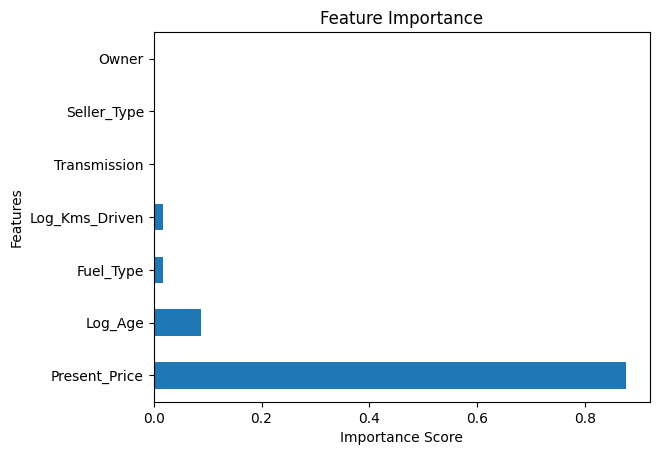

In [90]:
feature_importance.plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Feature importance analysis of the Gradient Boosting model indicates that Present_Price is the primary driver of car resale value, contributing approximately 87.6% of the predictive power. Log_Age also plays a role, reflecting the expected depreciation of vehicles over time. The remaining features, including Fuel_Type, Log_Kms_Driven, Transmission, Seller_Type, and Owner, contribute minimally to the model, suggesting that they have limited influence on the target variable in the presence of the dominant features. These insights confirm the model’s ability to focus on the most relevant predictors while ignoring less informative features.

In [91]:
import shap


In [92]:
# Assuming your model is already trained
explainer = shap.Explainer(model, X_train)

In [93]:
shap_values = explainer(X_train)

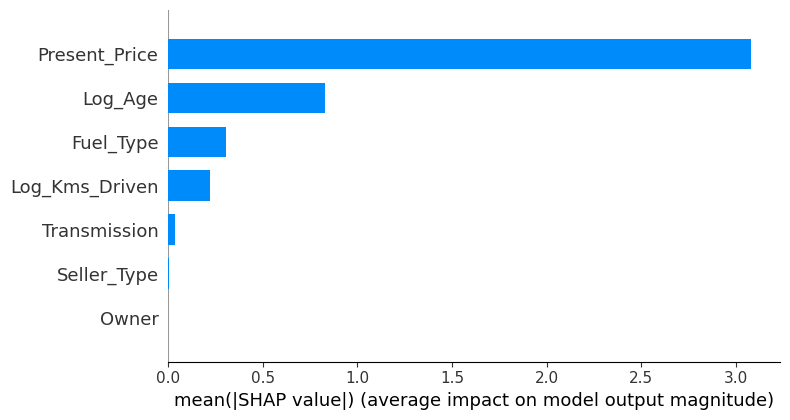

In [94]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

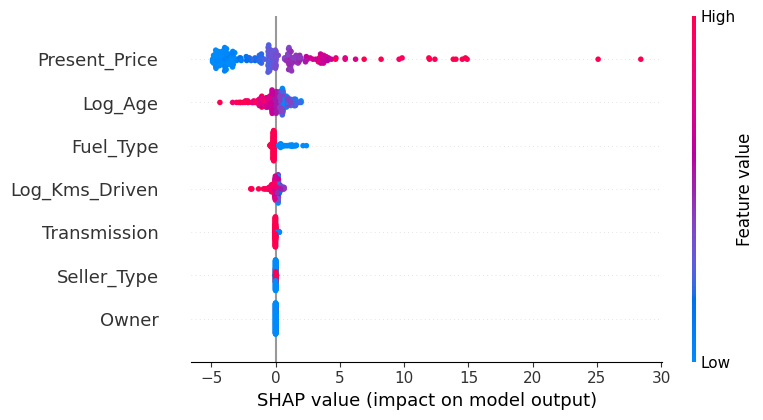

In [95]:
shap.summary_plot(shap_values, X_train)

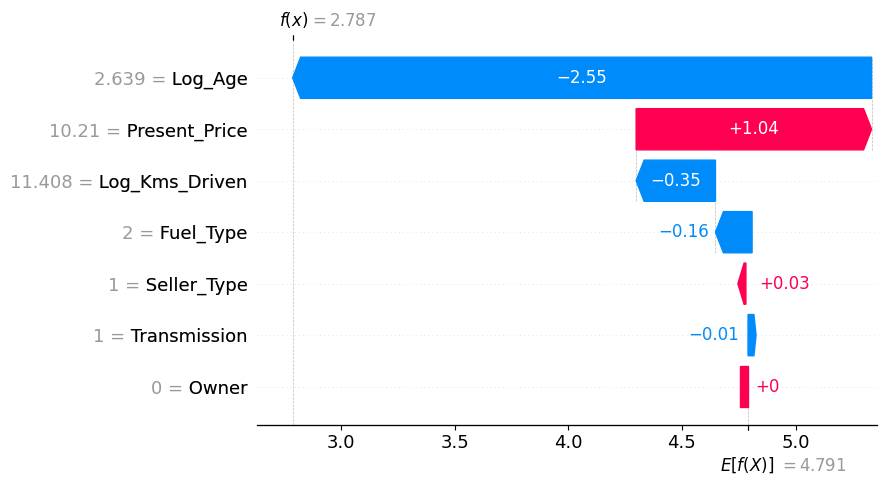

In [96]:
shap.plots.waterfall(shap_values[0])

SHAP values provide a detailed decomposition of the Gradient Boosting model’s predictions. Global SHAP importance confirms that Present_Price is the dominant predictor, followed by Log_Age. Beeswarm plots reveal how high and low feature values influence predictions across the dataset. Waterfall plots for individual predictions allow transparent, instance-level explanations, which enhance model interpretability and trust for stakeholders.

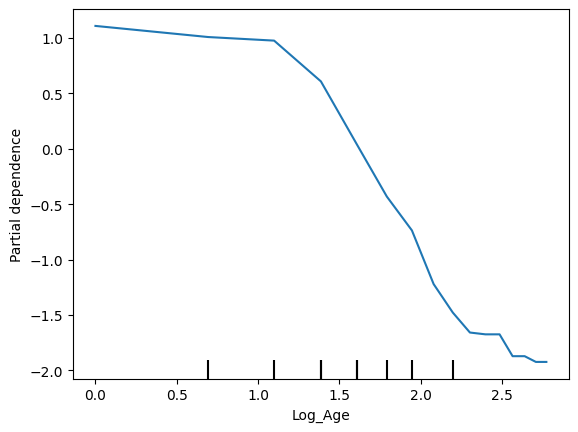

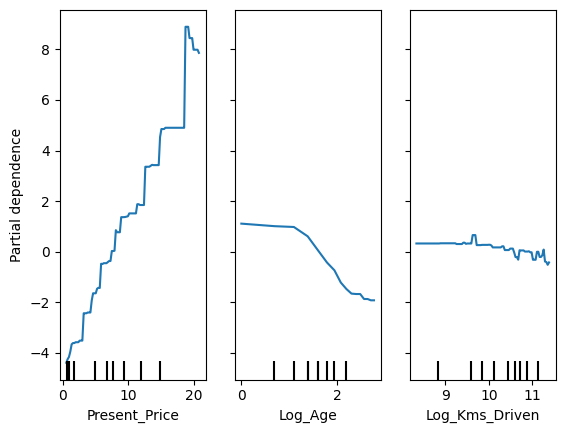

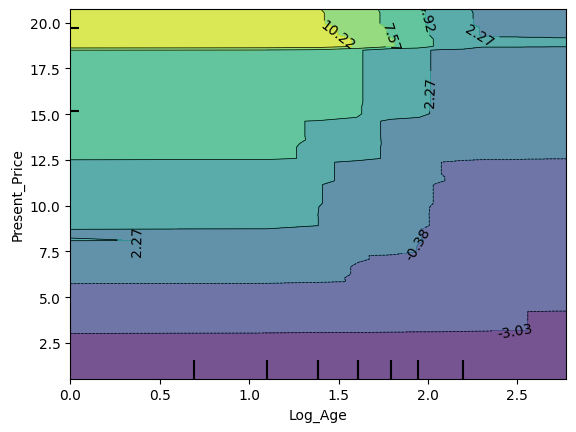

NameError: name 'y_test' is not defined

In [98]:
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

# Single feature PDP
PartialDependenceDisplay.from_estimator(model, X_train, features=['Log_Age'])
plt.show()

# Multiple features PDP
PartialDependenceDisplay.from_estimator(model, X_train, features=['Present_Price','Log_Age','Log_Kms_Driven'])
plt.show()

# Feature interaction PDP
PartialDependenceDisplay.from_estimator(model, X_train, features=[('Log_Age','Present_Price')])
plt.show()

# -------------------------------
# 7️⃣ Permutation Importance
# -------------------------------
perm_result = permutation_importance(model, X_test, y_test,
                                     n_repeats=10, random_state=42,
                                     scoring='r2')

perm_importance = pd.Series(perm_result.importances_mean, index=X_test.columns)
perm_importance = perm_importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
perm_importance.plot(kind='barh')
plt.title("Permutation Feature Importance")
plt.show()

# Print values for interpretation
print("Permutation Importance Scores:\n", perm_importance)